# Diffusion Model: SU3 gauge theory on $4^4$ lattice

*Sep 24, 2025*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

# Introduction

## Diffusion process on Lie group

Implements a diffusion process as described by the following stochastic     
    differential equation (SDE)                                                 
                                                                                
$$                                                                   
    \frac{d U(t)}{dt} = e^{\gamma t}\sqrt{2\gamma}\,  \eta(t)\, U(t)
$$
                                                                                
where $\gamma > 0$ controls the rate of increament in the noise variance,  
$\sigma > 0$ controls the overal scale of the noise,                
$\eta(t)$ is standard white Gaussian noise in the algebra space.    
This diffusion process governs the evolution of a state on a Lie group,     
with the time-dependent, variance-expanding noise.                          
                                                                                
The reverse process is defined by an SDE that uses a learned score function 
(the gradient of the log-probability density) to iteratively denoise the    
corrupted signal and recover clean samples.
$$                                                                   
    \frac{d U(t)}{dt} = \left((- e^{2 \gamma t} \gamma + \tilde \sigma^2(t)) s_t(U_t) +  \sqrt{2} \tilde \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element. As two specail cases, we can set $\tilde \sigma(t)$ to zero or to $e^{\gamma t} \sqrt{\gamma}$.

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
from lattice_ml.gauge_tools import WilsonGaugeAction
from lattice_ml.gauge_tools import GaugeLinkConv
from lattice_ml.gauge_tools import UNet, UNetEncoderLayer, UNetBottleneck, UNetDecoderLayer


from normflow.prior import SUnPrior

### Designing score function

The flow is defined as
$$                                                                   
    \frac{d U(t)}{dt} = \left((- e^{2 \gamma t} \gamma + \tilde \sigma^2(t)) s_t(U_t) +  \sqrt{2} \tilde \sigma(t) \eta(t)\right) U_t
$$
Here $s_t$ is in Lie-algebra element. As two specail cases, we can set $\tilde \sigma(t)$ to zero or to $e^{\gamma t} \sqrt{\gamma}$.


Below, we define a simple neural network for the score function.

In [ ]:
action = WilsonGaugeAction(beta=6)

def make_unet(spatial_ndim=4):
    """An example showing how to make an instance of UNet."""

    kwargs = {"spatial_ndim": spatial_ndim}

    # Encoding (contractive) path
    encoder_layers = [
        UNetEncoderLayer(channels=(1, 1), **kwargs),
    ]

    # bottleneck
    bottleneck = UNetBottleneck(channels=(1, 1), **kwargs)

    # Decoding (expansive) path
    decoder_layers = [
        UNetDecoderLayer(channels=(1, 1), **kwargs),
    ]

    return UNet(encoder_layers, bottleneck, decoder_layers)


class GaugeSU3AlgScoreFunc(torch.nn.Module):
    """
    An algebra-element score function for SU(3) matrices.

    This model takes as input the time `t` and the initial state matrix `x` and
    predicts a flow while ensuring the output remains antihermitian and traceless.
    """

    def __init__(self):
        """Initializes the SU3DynamicsFunc neural network."""
        super().__init__()

        self.weight = torch.nn.Parameter(torch.tensor([3/16, 0, 0, 0, 0]))
        self.powers = torch.arange(5).reshape(1, -1)
        self.unet = make_unet()
        
    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Computes the algebra-element score function for SU(3) matrices.

        Given a time `t` and a matrix `x`, the function processes the input
        through the neural network and applies post-processing to ensure the
        output is antihermitian and traceless.

        Args:
            - t (torch.Tensor): A 0D or 1D tensor representing time.
              If 1D, it is of shape (batch_size,)
            - x (torch.Tensor): A complex-valued input tensor of shape
              (batch_size, 1, 3, 3).

        Returns:
            - torch.Tensor: A antihermitian, traceless tensor of shape
              (batch_size, 1, 3, 3).
        """
        # x = self.link_conv1(x)
        shape = (-1, *[1]*(x.ndim - 1))
        x = self.unet(x, time=t)
        return action.algebra_force(x) 

    def time_func(self, t):
        """A polynomial function of time."""
        return torch.sum(self.weight * t.unsqueeze(-1) ** self.powers, dim=1)

In [4]:
training_samples = torch.load("/scratch/lturgut/cfgs_b6_200traj_15steps.pt")

from torch.utils.data import DataLoader, TensorDataset

batch_size = 256 // 4

dataset = TensorDataset(training_samples)

data_loader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)


In [5]:
from lattice_ml.diffusion.gauge import SUnDiffusionProcess

diffusion_process = SUnDiffusionProcess(GaugeSU3AlgScoreFunc())

In [6]:
from functools import partial

n_epochs = 0

train_kwargs = dict(
    n_epochs = n_epochs,
    hyperparam = dict(lr=0.003),
    checkpoint_dict = dict(print_every=50),
    scheduler = partial(
        torch.optim.lr_scheduler.CosineAnnealingLR,
        T_max = int(1.01 * n_epochs)              
    )
)


In [7]:
diffusion_process.train(data_loader, **train_kwargs)

Text(0, 0.5, 'Loss')

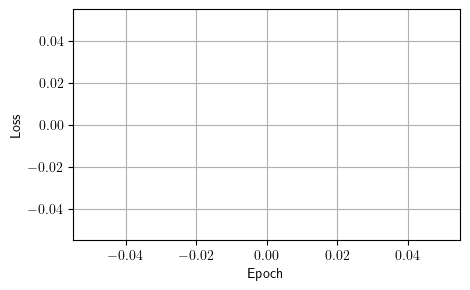

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

loss = diffusion_process.trainer.train_history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss, '.')


plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [9]:
num_samples, *sample_shape, n_c, n_c = training_samples.shape

prior = SUnPrior(n_c, sample_shape)

x = prior.sample(16)

with torch.no_grad():
    y = diffusion_process.reverse(x, sigma_tilde=0, step_size=0.003)

In [10]:
from lattice_ml.gauge_tools import compute_mean_reduced_trace_wilson_mxn_loop

In [11]:
(compute_mean_reduced_trace_wilson_mxn_loop(training_samples, 1, 1).mean(),
 compute_mean_reduced_trace_wilson_mxn_loop(y, 1, 1).mean(),
 compute_mean_reduced_trace_wilson_mxn_loop(y, 1, 1).std()
)

(tensor(0.5965),
 tensor(0.9965, device='cuda:0'),
 tensor(0.0045, device='cuda:0'))

In [12]:
from lattice_ml.gauge_tools import compute_wilson_1x1_loop


theta_x = torch.linalg.eig(compute_wilson_1x1_loop(x, 0, 1))[0].angle()
theta_y = torch.linalg.eig(compute_wilson_1x1_loop(y, 0, 1))[0].angle()

theta_test = torch.linalg.eig(compute_wilson_1x1_loop(training_samples, 0, 1))[0].angle()

In [13]:
grab = lambda x: x.detach().cpu().numpy()

theta_x = grab(theta_x)
theta_y = grab(theta_y)

theta_test = np.array([grab(q) for q in theta_test])

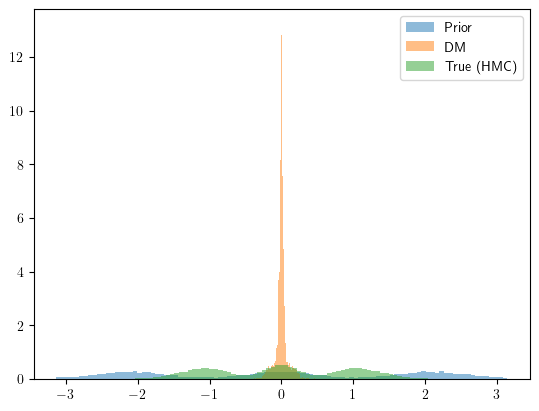

In [14]:
plt.hist(theta_x.ravel(), label = 'Prior', bins=100, density=True, alpha=0.5)
plt.hist(theta_y.ravel(), label = 'DM', bins=100, density=True, alpha=0.5)
plt.hist(theta_test.ravel(), label = 'True (HMC)', bins=100, density=True, alpha=0.5)

plt.legend();

In [15]:
diffusion_process.score_fn.weight * 16 / 3

tensor([0.2500, 0.0000, 0.0000, 0.0000, 0.0000], device='cuda:0',
       grad_fn=<DivBackward0>)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

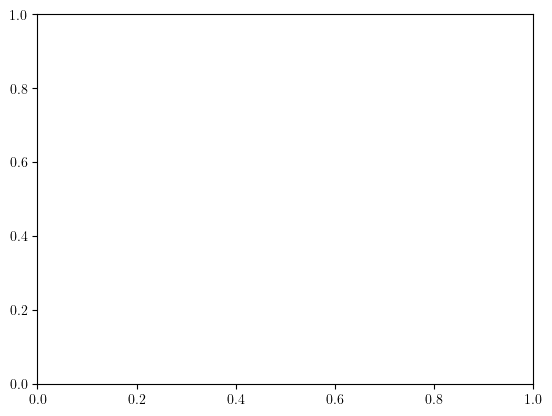

In [16]:
t = torch.linspace(0, 1, 101)

with torch.no_grad():
    plt.plot(t, 16 / 3 * diffusion_process.score_fn.time_func(t) * torch.exp(1 * t))
    plt.plot(t, 16 / 3 * diffusion_process.score_fn.time_func(t))

plt.grid()